<img src="https://raw.githubusercontent.com/egiuse25/APS/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Emilia Giusepponi

## Consigna  
En esta tarea continuaremos con el capítulo 14 de Holton. DSP Principles and App.

Comenzaremos con la generación de la siguiente señal:

$$x(k)=a_0⋅sen(Ω_1⋅n)+n_a(n)$$
siendo

$$a_0 = 2$$
$$Ω_1 = Ω0+fr ⋅ \frac{2π}{N}$$
$$Ω_0 = \frac{π}{2}$$


siendo la variable aleatoria definida por la siguiente distribución de probabilidad

$$f_r∼U(−2,2)$$


$$n_a∼N(0,σ^2)$$

Diseñe los siguientes estimadores,  de amplitud $a_1$


$$a^i_1=|X^i_w(Ω_0)|=|F{x(n)⋅w_i(n)}|$$


 y de frecuencia $Ω_1$


$$Ω^i_1=arg max_f{|X^i_w(Ω)|}$$

para cada una de las ventanas:

•rectangular (sin ventana), 

•flattop 

•blackmanharris

•otra que elija de scipy.signal.windows

Y siguiendo las siguientes consignas para su experimentación:

• Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.

• Parametrice para SNR's de 3 y 10 db (Ayuda: calibre $a_1$ para que la potencia de la senoidal sea 1 W).

Se pide:

1) Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas rectangular (sin ventana), flattop y blackmanharris y otras que considere. 

**Ayuda**: Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$$
\hat{a}_0 = \left| X_i^w(\Omega_0) \right|
$$

siendo

$$
s_a = E\{\hat{a}_0\} - a_0
$$

$$
v_a = \mathrm{var}\{\hat{a}_0\}
= E\left\{(\hat{a}_0 - E\{\hat{a}_0\})^2\right\}
$$

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales

$$
E\{\hat{a}_0\} = \hat{\mu}_a =
\frac{1}{M}\sum_{j=0}^{M-1}\hat{a}_j
$$

$$
s_a = \hat{\mu}_a - a_0
$$

$$
v_a =
\frac{1}{M}\sum_{j=0}^{M-1}
(\hat{a}_j - \hat{\mu}_a)^2
$$

**Bonus**:

💎 Analice el efecto del zero-padding para el estimador $\hat{Ω}_1$
 
🤯 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.


Bonus

Visualizar los 3 histogramas juntos

## Desarrollo

Para definir a la señal previamente mencionada $x(k)$ se comienza definiendo los parámetros de una señal senoidal.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


def mi_funcion_sen(ao, dc, ff, ph, N, fs):
    ts = 1 / fs
    tt = np.arange(0, N) * ts
    xx = dc + ao * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx


ao = np.sqrt(2)
dc = 0
ph = 0 
N = 1000
L = N * 10
fs = 1000
ff = fs/N
df = fs/N #resolucion espectral 

N = 1000
R = 200
Ts = 1/fs

tt,xx = mi_funcion_sen(ao, dc,ff,ph,N,fs)

Posteriormente, se va genera un vector para las frecuencias de un tamaño de R, siendo R el número total de realizaciones, con distribución uniforme entre -2 y 2. Además, también se generará un vector de tamaño (1,N) siendo N el número total de muestras en el tiempo. En este caso, R tiene un valor de 200 y N un tamaño de 1000.

In [2]:
fr = np.random.uniform(-2,2,R)
omega_0 = N/4
omega_1 = omega_0 + fr 
f1 = omega_1 * df

#MATRIZ RxN
N = 1000
R = 200
Ts = 1/fs

N_vector = tt.reshape((1,N))

matriz_N = np.tile(N_vector, ((R,1)))
matriz_f1 = (np.tile(f1, ((N,1)))).T

matriz_senoidal = (ao * np.sin(2*np.pi*matriz_N*matriz_f1))

MM = np.fft.fft(matriz_senoidal,  axis=1)/N
MMmod = np.abs(MM) # MODULO
MMesp_db = 20 * np.log10(MMmod + 1e-12 ) # ESPECTRO POTENCIA 

### Primer caso: SNR de 10 dB

Posteriormente, para calcular los estimadores: 

<Figure size 1000x600 with 0 Axes>

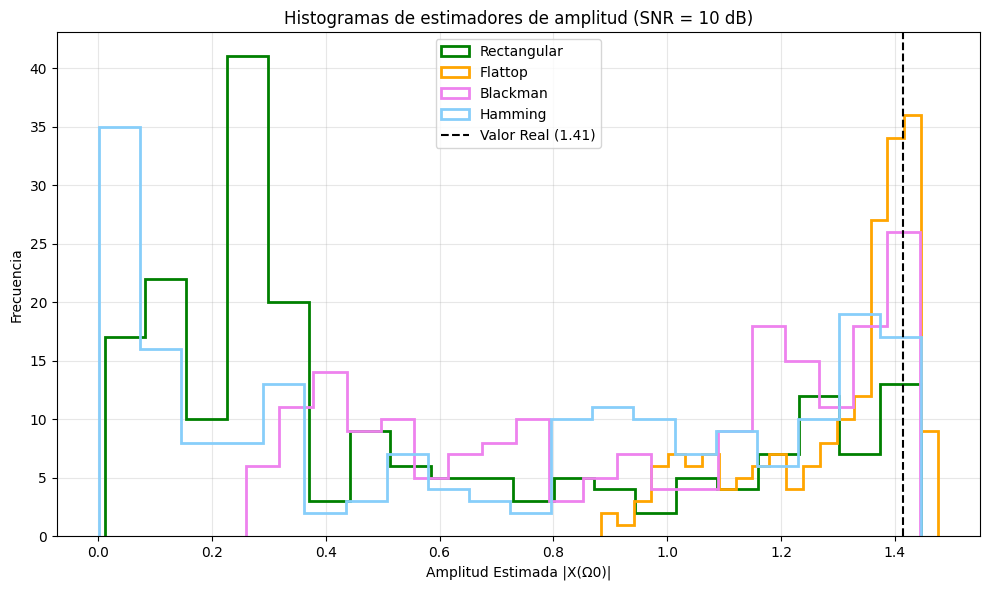

In [3]:
'ESTIMADORES AMPLITUD'
mu = 0
SNR_db = 10

sigma = np.sqrt(10**(-SNR_db/10))
ruido_blanco = np.random.normal(mu,sigma,(R,N)) #VECTOR RUIDO BLANCO DE RXN

x_k = matriz_senoidal + ruido_blanco

'----RECTANGULAR-----'
XX_KK = np.fft.fft(x_k, axis=1)/N
estimador_amplitud_rectangular = 2*np.abs(XX_KK[:,N//4]) # ESTIMADOR AMPLITUD EVALUADO EN  -> estimador de energia

'----FLATTOP-----'
flattop = signal.windows.flattop (N)
x_flatt = x_k * flattop
XX_flatt = np.fft.fft(x_flatt, axis=1)/np.sum(flattop)
estimador_amplitud_flattop = 2*np.abs(XX_flatt[:,N//4]) 

'----BLACKMAN-----'
blackman = signal.windows.blackmanharris(N)
x_blackman = x_k * blackman
XX_blackman = np.fft.fft(x_blackman, axis=1)/np.sum(blackman)
estimador_amplitud_blackman = 2*np.abs(XX_blackman[:,N//4]) 

'----HAMMING-----'
hamming = signal.windows.hamming(N)
x_hamming = x_k * hamming
XX_hamming = np.fft.fft(x_hamming,  axis=1)/np.sum(hamming)
estimador_amplitud_hamming = 2*np.abs(XX_hamming[:,N//4]) 

##GRAFICOS ESTIMADOR AMPLITUD 
plt.figure(figsize=(10,6))
plt.figure(figsize=(10, 6)) 

plt.hist(estimador_amplitud_rectangular, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_amplitud_flattop, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_amplitud_blackman, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_amplitud_hamming, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.axvline(x=ao, color='black', linestyle='--', label=f'Valor Real ({ao:.2f})')
plt.title('Histogramas de estimadores de amplitud (SNR = 10 dB)')
plt.xlabel('Amplitud Estimada |X(Ω0)|')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Se puede observar cómo la distribución de la ventana rectangular está muy desplazada hacia la izquierda debido a que arrojó repetidamente resultados muy alejados a la amplitud real de la señal. Esto la convierte en un estimador más sensible a las variaciones de frecuencia. Para el estimador de la ventana Flattop, se observa cómo está centrada hacia la derecha, centrada alrededor de $\sqrt{2}$, indicando que es un estimador más estable frente a corrimientos frecuenciales que el previamente mencionado. Esto se debe a que en su espectro, el lóbulo principal se mantiene en una amplitud constante a medida que las frecuencias varían, lo cual permite capturar la amplitud máxima de la señal en dichos puntos. Por otro lado, tanto para Blackman-Harris como para Hamming, si bien se ve un resultado similar el de Flattop pero menos pronunciado, sus valores se encuentran visiblemente alejados de la amplitud real de la señal.

In [16]:
import pandas as pd
'-----------------------SESGOS AMPLITUD------------------'
sesgo_amplitud_rectangular_10db = np.mean(estimador_amplitud_rectangular) - ao 
sesgo_amplitud_flattop_10db = np.mean(estimador_amplitud_flattop) - ao 
sesgo_amplitud_blackman_10db = np.mean(estimador_amplitud_blackman) - ao 
sesgo_amplitud_hamming_10db = np.mean(estimador_amplitud_hamming) - ao 

'-----------------------VARIANZAS AMPLITUD-----------------------'
varianza_amplitud_rectangular_10db = np.var(estimador_amplitud_rectangular) 
varianza_amplitud_flattop_10db = np.var(estimador_amplitud_flattop) 
varianza_amplitud_blackman_10db = np.var(estimador_amplitud_blackman) 
varianza_amplitud_hamming_10db = np.var(estimador_amplitud_hamming) 

datos_amplitud_10 = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_amplitud_rectangular_10db, sesgo_amplitud_flattop_10db, sesgo_amplitud_blackman_10db, sesgo_amplitud_hamming_10db],
    "Varianza (va)": [varianza_amplitud_rectangular_10db, varianza_amplitud_flattop_10db, varianza_amplitud_blackman_10db, varianza_amplitud_hamming_10db]
}
df_amplitud_10 = pd.DataFrame(datos_amplitud_10).set_index("Estimador")

print("=== ESTIMACIÓN DE AMPLITUD (SNR = 10 dB) ===")
display(df_amplitud_10.round(4))

=== ESTIMACIÓN DE AMPLITUD (SNR = 10 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,-0.8544,0.2051
Flat-top,-0.1190,0.0261
Blackman-Harris,-0.4714,0.1459
Hamming,-0.7221,0.2568


Mediante el cálculo de los sesgos se pudo observar que el estimador más insesgado es el de la ventana de Flattop. El peor resultado fue el de la ventana rectangular debido a que su lóbulo principal es demasiado estrecho, lo que produce mayores errores al estimar la amplitud. Con respecto a Blackman-Harris y Hamming, ambas ventanas ensanchan su lóbulo principal en comparación a la rectangular. Sin embargo, como el lóbulo de Blackman-Harris es más ancho que el de Hamming, es más tolerante a los corrimientos de frecuencia, siendo el sesgo es comparativamente mejor. 

Por otro lado, la varianza define qué tan distintos son los resultados obtenidos entre sí. Tiene sentido que para la ventana de Flattop se haya obtenido un resultado tan chico debido a que es el estimador de amplitud más estable. Al analizar Blackman-Harris y Hamming, se observa que la varianza es menor para Blackman-Harris debido a que tiene el lóbulo principal más ancho que el de Hamming, haciendo que la amplitud varíe de forma menos abrupta ante corrimientos de frecuencia. 

Con respecto a la ventana rectangular y a Hamming, se observa que la de mayor varianza entre ellas es la segunda mencionada. Esto es debido a que si bien Hamming es un mejor estimador que la ventana rectangular, la varianza se ve influenciada por el ancho del lóbulo principal de cada una. Si bien la ventana rectangular produce estimaciones más sesgadas, se evidencia gráficamente como muchas de ellas se concentran alrededor de valores bajos similares entre sí. En cambio, la ventana de Hamming presenta una respuesta más gradual frente a corrimientos frecuenciales, generando una distribución de amplitudes más dispersa y, por lo tanto, una mayor varianza.

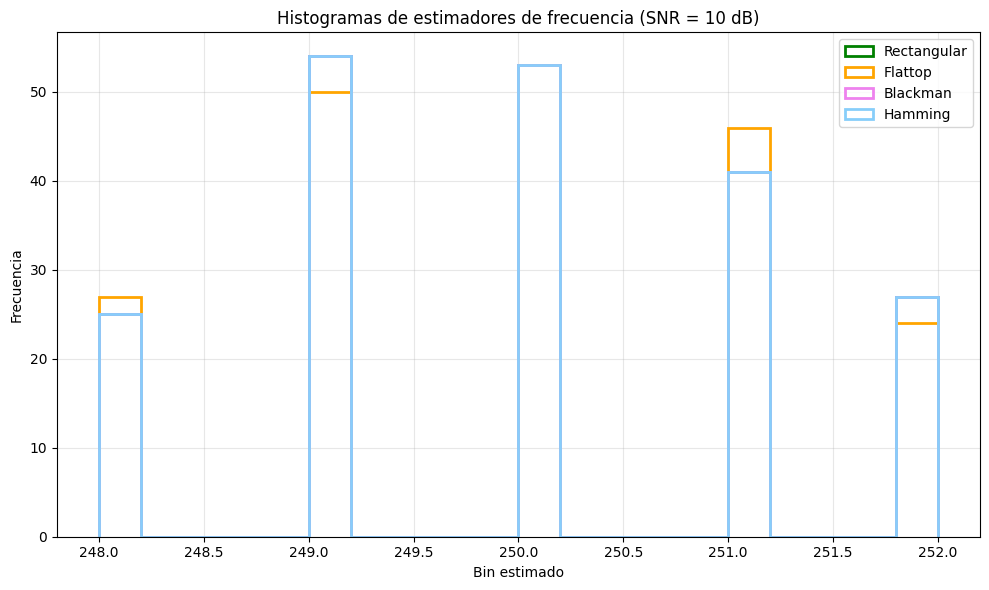

In [5]:
'----RECTANGULAR-----'
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia_rectangular = np.argmax(XX_KK_mod[:,:N//2], axis=1)

'----FLATTOP-----'
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop = np.argmax(XX_flat_mod[:,:N//2], axis=1)

'----BLACKMAN-----'
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman = np.argmax(XX_blackman_mod[:,:N//2], axis=1)

'----HAMMING-----'
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming = np.argmax(XX_hamming_mod[:,:N//2], axis=1)


##GRAFICOS ESTIMADOR FRECUENCIA 
plt.figure(figsize=(10, 6)) 

plt.hist(estimador_frecuencia_rectangular, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_frecuencia_flattop, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_frecuencia_blackman, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_frecuencia_hamming, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.title('Histogramas de estimadores de frecuencia (SNR = 10 dB)')
plt.xlabel('Bin estimado')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En este caso, para el histograma de los estimadores de frecuencia, se puede notar como se superponen entre sí para casi todas las ventanas. Además, se puede apreciar como la mayor cantidad de resultados de frecuencias obtenidas están en el valor del bin 250, el cual es donde está $Ω_0$.

In [20]:
'-------------------SESGOS FRECUENCIA-------------------'
sesgo_frecuencia_rectangular_10db = np.mean(estimador_frecuencia_rectangular - omega_1)
sesgo_frecuencia_flattop_10db = np.mean(estimador_frecuencia_flattop - omega_1)
sesgo_frecuencia_blackman_10db = np.mean(estimador_frecuencia_blackman - omega_1)
sesgo_frecuencia_hamming_10db = np.mean(estimador_frecuencia_hamming - omega_1)

'-------------------VARIANZA FRECUENCIA-------------------'
varianza_frecuencia_rectangular_10db = np.var(estimador_frecuencia_rectangular) 
varianza_frecuencia_flattop_10db = np.var(estimador_frecuencia_flattop) 
varianza_frecuencia_blackman_10db = np.var(estimador_frecuencia_blackman) 
varianza_frecuencia_hamming_10db = np.var(estimador_frecuencia_hamming) 

datos_frecuencia_10 = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_frecuencia_rectangular_10db, sesgo_frecuencia_flattop_10db, sesgo_frecuencia_blackman_10db, sesgo_frecuencia_hamming_10db],
    "Varianza (va)": [varianza_frecuencia_rectangular_10db, varianza_frecuencia_flattop_10db, varianza_frecuencia_blackman_10db, varianza_frecuencia_hamming_10db]
}
df_frecuencia_10 = pd.DataFrame(datos_frecuencia_10).set_index("Estimador")

print("=== ESTIMACIÓN DE FRECUENCIA (SNR = 10 dB) ===")
display(df_frecuencia_10.round(4))

=== ESTIMACIÓN DE FRECUENCIA (SNR = 10 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,0.0045,1.5175
Flat-top,0.0345,1.3396
Blackman-Harris,-0.0055,1.4964
Hamming,0.0045,1.5175


A diferencia del caso anterior, donde se observaban los sesgos de los estimadores de amplitud, se obtienen valores muy cercanos a cero para todos los sesgos de todos los estimadores frecuenciales. Por lo que, se podrían considerar como insesgados. 

Las varianzas de los estimadores de frecuencia resultan muy similares entre sí para todas las ventanas analizadas. Esto está intimamente relacionado con el espacio entre bins debido a que este último no es suficiente para que cada ventana afecte significativamente a la estimación de la frecuencia y, por lo tanto, resultan poco apreciables.

### Segundo caso: SNR de 3 dB

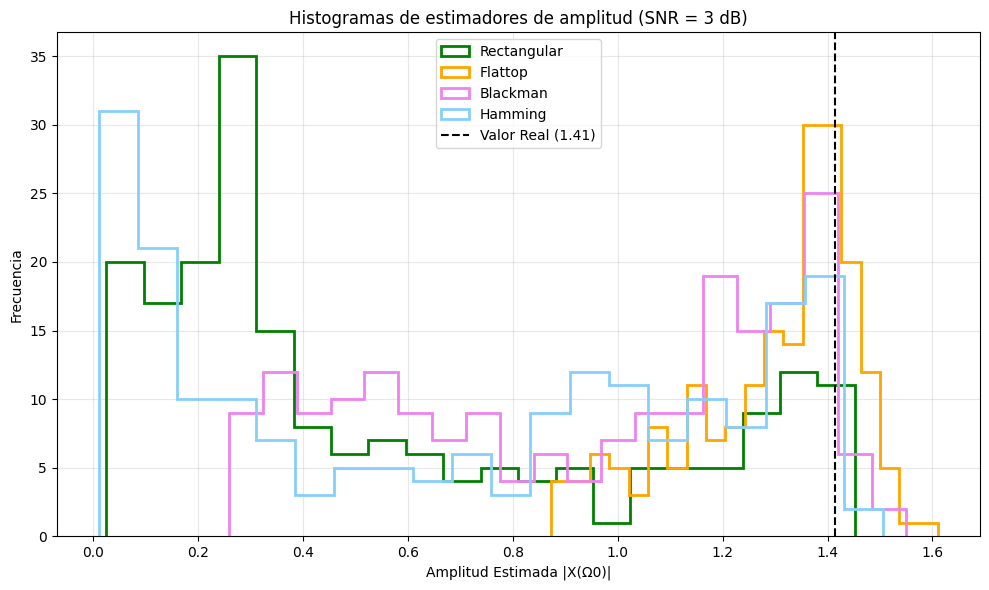

In [7]:
'ESTIMADORES AMPLITUD'
mu = 0
SNR_db = 3

sigma = np.sqrt(10**(-SNR_db/10))
ruido_blanco = np.random.normal(mu,sigma,(R,N)) #VECTOR RUIDO BLANCO DE RXN

x_k = matriz_senoidal + ruido_blanco

'----RECTANGULAR----'
XX_KK = np.fft.fft(x_k, axis=1)/N
estimador_amplitud_rectangular = 2*np.abs(XX_KK[:,N//4]) # ESTIMADOR AMPLITUD EVALUADO EN  -> estimador de energia

'----FLATTOP----'
flattop = signal.windows.flattop (N)
x_flatt = x_k * flattop
XX_flatt = np.fft.fft(x_flatt, axis=1)/np.sum(flattop)
estimador_amplitud_flattop = 2*np.abs(XX_flatt[:,N//4]) 

'----BLACKMAN----'
blackman = signal.windows.blackmanharris(N)
x_blackman = x_k * blackman
XX_blackman = np.fft.fft(x_blackman, axis=1)/np.sum(blackman)
estimador_amplitud_blackman = 2*np.abs(XX_blackman[:,N//4]) 

'----HAMMING----'
hamming = signal.windows.hamming(N)
x_hamming = x_k * hamming
XX_hamming = np.fft.fft(x_hamming,  axis=1)/np.sum(hamming)
estimador_amplitud_hamming = 2*np.abs(XX_hamming[:,N//4]) 

##GRAFICOS ESTIMADOR AMPLITUD 
plt.figure(figsize=(10,6))

plt.hist(estimador_amplitud_rectangular, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_amplitud_flattop, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_amplitud_blackman, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_amplitud_hamming, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.axvline(x=ao, color='black', linestyle='--', label=f'Valor Real ({ao:.2f})')

plt.title('Histogramas de estimadores de amplitud (SNR = 3 dB)')
plt.xlabel('Amplitud Estimada |X(Ω0)|')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En comparación con el caso previo, donde la SNR tenía un valor de 10 dB, se puede observar como las ventanas se comportan de una manera similar al anterior. 

In [15]:
'-----------------------SESGOS AMPLITUD------------------'
sesgo_amplitud_rectangular_3db = np.mean(estimador_amplitud_rectangular) - ao 
sesgo_amplitud_flattop_3db = np.mean(estimador_amplitud_flattop) - ao 
sesgo_amplitud_blackman_3db = np.mean(estimador_amplitud_blackman) - ao 
sesgo_amplitud_hamming_3db = np.mean(estimador_amplitud_hamming) - ao 

'-----------------------VARIANZAS AMPLITUD-----------------------'
varianza_amplitud_rectangular_3db = np.var(estimador_amplitud_rectangular) 
varianza_amplitud_flattop_3db = np.var(estimador_amplitud_flattop) 
varianza_amplitud_blackman_3db = np.var(estimador_amplitud_blackman) 
varianza_amplitud_hamming_3db = np.var(estimador_amplitud_hamming) 

datos_amplitud_3 = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_amplitud_rectangular_3db, sesgo_amplitud_flattop_3db, sesgo_amplitud_blackman_3db, sesgo_amplitud_hamming_3db],
    "Varianza (va)": [varianza_amplitud_rectangular_3db, varianza_amplitud_flattop_3db, varianza_amplitud_blackman_3db, varianza_amplitud_hamming_3db]
}
df_amplitud_3 = pd.DataFrame(datos_amplitud_3).set_index("Estimador")

print("=== ESTIMACIÓN DE AMPLITUD (SNR = 3 dB) ===")
display(df_amplitud_3.round(4))

=== ESTIMACIÓN DE AMPLITUD (SNR = 3 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,-0.8544,0.2051
Flat-top,-0.1190,0.0261
Blackman-Harris,-0.4714,0.1459
Hamming,-0.7221,0.2568


Los sesgos obtenidos en el caso de los estimadores de amplitud fueron más sesgados que los del caso anterior. Sin embargo, mantienen exactamente sus respectivos comportamientos al igual que en el cálculo de la varianza. 

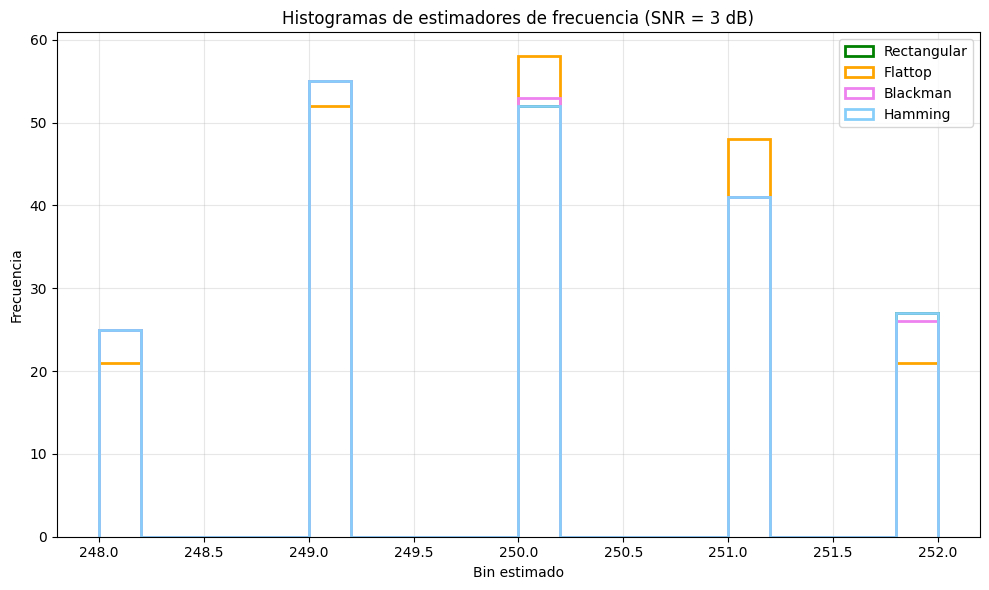

In [9]:
'----RECTANGULAR----'
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia_rectangular = np.argmax(XX_KK_mod[:,:N//2], axis=1)

'----FLATTOP-----'
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop = np.argmax(XX_flat_mod[:,:N//2], axis=1)

'----BLACKMAN-----'
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman = np.argmax(XX_blackman_mod[:,:N//2], axis=1)

'----HAMMING-----'
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming = np.argmax(XX_hamming_mod[:,:N//2], axis=1)


##GRAFICOS ESTIMADOR FRECUENCIA 
plt.figure(figsize=(10, 6)) 

plt.hist(estimador_frecuencia_rectangular, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_frecuencia_flattop, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_frecuencia_blackman, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_frecuencia_hamming, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.title('Histogramas de estimadores de frecuencia (SNR = 3 dB)')
plt.xlabel('Bin estimado')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
'-----------------------SESGOS FRECUENCIA------------------'
sesgo_frecuencia_rectangular_3db = np.mean(estimador_frecuencia_rectangular - omega_1)
sesgo_frecuencia_flattop_3db = np.mean(estimador_frecuencia_flattop - omega_1)
sesgo_frecuencia_blackman_3db = np.mean(estimador_frecuencia_blackman - omega_1)
sesgo_frecuencia_hamming_3db = np.mean(estimador_frecuencia_hamming - omega_1)

'-----------------------VARIANZAS FRECUENCIA------------------'
varianza_frecuencia_rectangular_3db = np.var(estimador_frecuencia_rectangular) 
varianza_frecuencia_flattop_3db = np.var(estimador_frecuencia_flattop) 
varianza_frecuencia_blackman_3db = np.var(estimador_frecuencia_blackman) 
varianza_frecuencia_hamming_3db = np.var(estimador_frecuencia_hamming) 

datos_frecuencia_3 = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_frecuencia_rectangular_3db, sesgo_frecuencia_flattop_3db, sesgo_frecuencia_blackman_3db, sesgo_frecuencia_hamming_3db],
    "Varianza (va)": [varianza_frecuencia_rectangular_3db, varianza_frecuencia_flattop_3db, varianza_frecuencia_blackman_3db, varianza_frecuencia_hamming_3db]
}
df_frecuencia_3 = pd.DataFrame(datos_frecuencia_3).set_index("Estimador")

print("=== ESTIMACIÓN DE FRECUENCIA (SNR = 3 dB) ===")
display(df_frecuencia_3.round(4))

=== ESTIMACIÓN DE FRECUENCIA (SNR = 3 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,0.0045,1.5175
Flat-top,0.0345,1.3396
Blackman-Harris,-0.0055,1.4964
Hamming,0.0045,1.5175


Para los sesgos se obtienen resultados muy cercanos a cero, por lo que se los puede considerar nuevamente como insesgados. Por último, la varianza de los estimadores frecuenciales no fluctúan mucho entre sí.

### Bonus: Zero-padding

Para el caso donde la SNR es 10 dB se recalculan los estimadores frecuenciales. 

<Figure size 1000x600 with 0 Axes>

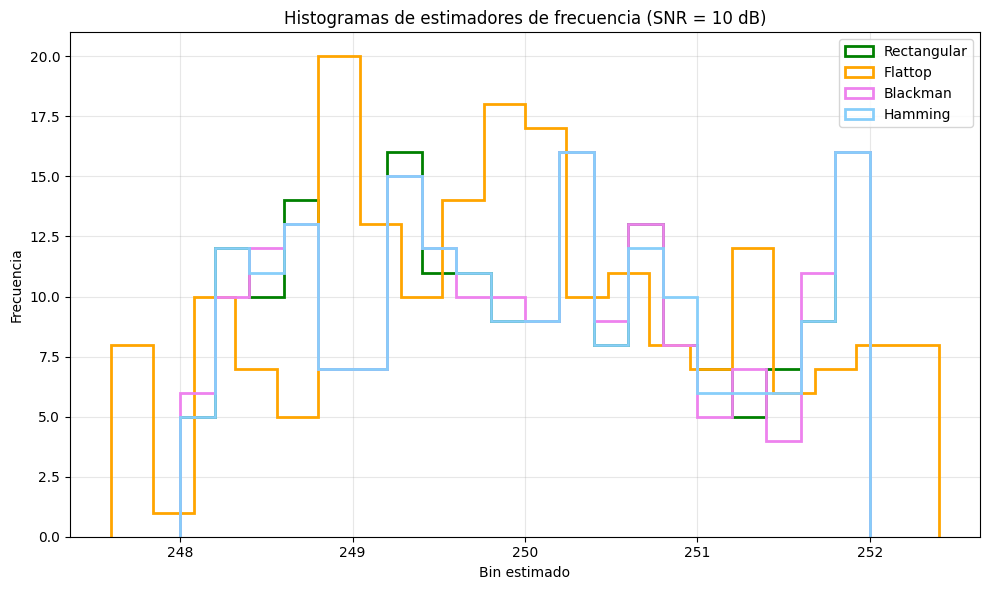

In [11]:
'----------------ESTIMADORES FRECUENCIA CON ZEROPADDING----------------'
mu = 0
SNR_db = 10

sigma = np.sqrt(10**(-SNR_db/10))
ruido_blanco = np.random.normal(mu,sigma,(R,N)) #VECTOR RUIDO BLANCO DE RXN

x_k = matriz_senoidal + ruido_blanco

'----RECTANGULAR-----'
XX_KK = np.fft.fft(x_k, n=L,  axis=1)/N
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia_rectangular_zp = np.argmax(XX_KK_mod[:,:L//2], axis=1)

'----FLATTOP-----'
flattop = signal.windows.flattop (N)
x_flatt = x_k * flattop
XX_flatt = np.fft.fft(x_flatt, n=L,  axis=1)/np.sum(flattop)
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop_zp = np.argmax(XX_flat_mod[:,:L//2], axis=1)

'----BLACKMAN-----'
blackman = signal.windows.blackmanharris(N)
x_blackman = x_k * blackman
XX_blackman = np.fft.fft(x_blackman, n=L,  axis=1)/np.sum(blackman)
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman_zp = np.argmax(XX_blackman_mod[:,:L//2], axis=1)

'----HAMMING-----'
hamming = signal.windows.hamming(N)
x_hamming = x_k * hamming
XX_hamming = np.fft.fft(x_hamming, n=L,  axis=1)/np.sum(hamming)
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming_zp = np.argmax(XX_hamming_mod[:,:L//2], axis=1)

##GRAFICOS ESTIMADOR AMPLITUD 
plt.figure(figsize=(10,6))
plt.figure(figsize=(10, 6)) 

plt.hist(estimador_frecuencia_rectangular_zp/10, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_frecuencia_flattop_zp/10, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_frecuencia_blackman_zp/10, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_frecuencia_hamming_zp/10, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.title('Histogramas de estimadores de frecuencia (SNR = 10 dB)')
plt.xlabel('Bin estimado')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Para el histograma de estimadores de frecuencia con zero-padding, si bien se mantiene dentro del mismo rango de bins, se puede notar en este caso cómo se obtiene una distribución mucho más uniforme que en la que no tenía zero-padding. 

In [19]:
#%%
'-----------------------SESGOS FRECUENCIA CON ZEROPADDING------------------'
###SESGOS FRECUENCIAS
sesgo_frecuencia_rectangular_zp = np.mean(estimador_frecuencia_rectangular_zp/10 - omega_1)
sesgo_frecuencia_flattop_zp = np.mean(estimador_frecuencia_flattop_zp/10 - omega_1)
sesgo_frecuencia_blackman_zp = np.mean(estimador_frecuencia_blackman_zp/10 - omega_1)
sesgo_frecuencia_hamming_zp = np.mean(estimador_frecuencia_hamming_zp/10 - omega_1)
'-----------------------VARIANZAS FRECUENCIA CON ZEROPADDING-----------------------'
##FRECUENCIA
varianza_frecuencia_rectangular_zp = np.var(estimador_frecuencia_rectangular_zp/10) 
varianza_frecuencia_flattop_zp = np.var(estimador_frecuencia_flattop_zp/10) 
varianza_frecuencia_blackman_zp = np.var(estimador_frecuencia_blackman_zp/10) 
varianza_frecuencia_hamming_zp = np.var(estimador_frecuencia_hamming_zp/10) 

datos_frecuencia_zp = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_frecuencia_rectangular_zp, sesgo_frecuencia_flattop_zp, sesgo_frecuencia_blackman_zp, sesgo_frecuencia_hamming_zp],
    "Varianza (va)": [varianza_frecuencia_rectangular_zp, varianza_frecuencia_flattop_zp, varianza_frecuencia_blackman_zp, varianza_frecuencia_hamming_zp]
}
df_frecuencia_zp = pd.DataFrame(datos_frecuencia_zp).set_index("Estimador")

print("=== ESTIMACIÓN DE FRECUENCIA CON ZERO-PADDING (SNR = 10 dB) ===")
display(df_frecuencia_zp.round(4))

=== ESTIMACIÓN DE FRECUENCIA CON ZERO-PADDING (SNR = 10 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,-0.0005,1.2881
Flat-top,-0.0010,1.4925
Blackman-Harris,-0.0025,1.2843
Hamming,-0.0015,1.2820


Al aplicar el fenómeno de zero-padding, los sesgos obtenidos para los estimadores frecuenciales dieron, en magnitud, más pequeños que en el anterior caso. Por lo tanto, se pueden considerar insesgados nuevamente. 

En el análisis de la varianza con zero-padding, se logró reducir el valor con respecto al caso donde no se le aplica. Además, se observa numéricamente un resultado muy similar entre la ventana rectangular, la de Blackman-Harris y la de Hamming. Sin embargo, la varianza de la ventana de Flattop se mantiene como la más grande debido a que su lóbulo principal se mantiene en una amplitud constante sin importar la frecuencia, lo que hace que no se pueda diferenciar entre bins. 

Para el caso de los 3 dB se observan los siguientes resultados:

<Figure size 1000x600 with 0 Axes>

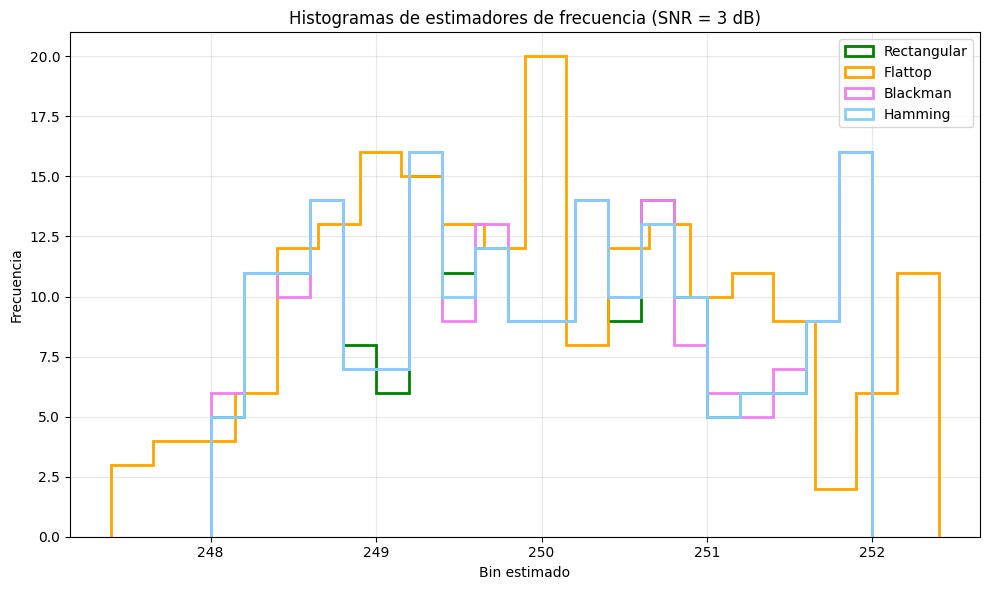

In [13]:
'----------------ESTIMADORES FRECUENCIA CON ZEROPADDING----------------'
mu = 0
SNR_db = 3

sigma = np.sqrt(10**(-SNR_db/10))
ruido_blanco = np.random.normal(mu,sigma,(R,N)) #VECTOR RUIDO BLANCO DE RXN

x_k = matriz_senoidal + ruido_blanco

'----RECTANGULAR-----'
XX_KK = np.fft.fft(x_k, n=L,  axis=1)/N
XX_KK_mod = np.abs(XX_KK)
estimador_frecuencia_rectangular_zp = np.argmax(XX_KK_mod[:,:L//2], axis=1)

'----FLATTOP-----'
flattop = signal.windows.flattop (N)
x_flatt = x_k * flattop
XX_flatt = np.fft.fft(x_flatt, n=L,  axis=1)/np.sum(flattop)
XX_flat_mod = np.abs(XX_flatt)
estimador_frecuencia_flattop_zp = np.argmax(XX_flat_mod[:,:L//2], axis=1)

'----BLACKMAN-----'
blackman = signal.windows.blackmanharris(N)
x_blackman = x_k * blackman
XX_blackman = np.fft.fft(x_blackman, n=L,  axis=1)/np.sum(blackman)
XX_blackman_mod = np.abs(XX_blackman)
estimador_frecuencia_blackman_zp = np.argmax(XX_blackman_mod[:,:L//2], axis=1)

'----HAMMING-----'
hamming = signal.windows.hamming(N)
x_hamming = x_k * hamming
XX_hamming = np.fft.fft(x_hamming, n=L,  axis=1)/np.sum(hamming)
XX_hamming_mod = np.abs(XX_hamming)
estimador_frecuencia_hamming_zp = np.argmax(XX_hamming_mod[:,:L//2], axis=1)

##GRAFICOS ESTIMADOR AMPLITUD 
plt.figure(figsize=(10,6))
plt.figure(figsize=(10, 6)) 

plt.hist(estimador_frecuencia_rectangular_zp/10, bins=20, histtype='step', linewidth=2, label='Rectangular', color='green')
plt.hist(estimador_frecuencia_flattop_zp/10, bins=20, histtype='step', linewidth=2, label='Flattop', color='orange')
plt.hist(estimador_frecuencia_blackman_zp/10, bins=20, histtype='step', linewidth=2, label='Blackman', color='violet')
plt.hist(estimador_frecuencia_hamming_zp/10, bins=20, histtype='step', linewidth=2, label='Hamming', color='lightskyblue')

plt.title('Histogramas de estimadores de frecuencia (SNR = 3 dB)')
plt.xlabel('Bin estimado')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
'-----------------------SESGOS FRECUENCIA CON ZEROPADDING------------------'
sesgo_frecuencia_rectangular_zp_3db = np.mean(estimador_frecuencia_rectangular_zp/10 - omega_1)
sesgo_frecuencia_flattop_zp_3db = np.mean(estimador_frecuencia_flattop_zp/10 - omega_1)
sesgo_frecuencia_blackman_zp_3db = np.mean(estimador_frecuencia_blackman_zp/10 - omega_1)
sesgo_frecuencia_hamming_zp_3db = np.mean(estimador_frecuencia_hamming_zp/10 - omega_1)

'-----------------------VARIANZAS FRECUENCIA CON ZEROPADDING-----------------------'
varianza_frecuencia_rectangular_zp_3db = np.var(estimador_frecuencia_rectangular_zp/10) 
varianza_frecuencia_flattop_zp_3db = np.var(estimador_frecuencia_flattop_zp/10) 
varianza_frecuencia_blackman_zp_3db = np.var(estimador_frecuencia_blackman_zp/10) 
varianza_frecuencia_hamming_zp_3db = np.var(estimador_frecuencia_hamming_zp/10) 

datos_frecuencia_zp_3db = {
    "Estimador": ["Rectangular", "Flat-top", "Blackman-Harris", "Hamming"],
    "Sesgo (sa)": [sesgo_frecuencia_rectangular_zp_3db, sesgo_frecuencia_flattop_zp_3db, sesgo_frecuencia_blackman_zp_3db, sesgo_frecuencia_hamming_zp_3db],
    "Varianza (va)": [varianza_frecuencia_rectangular_zp_3db, varianza_frecuencia_flattop_zp_3db, varianza_frecuencia_blackman_zp_3db, varianza_frecuencia_hamming_zp_3db]
}
df_frecuencia_zp_3db = pd.DataFrame(datos_frecuencia_zp_3db).set_index("Estimador")

print("=== ESTIMACIÓN DE FRECUENCIA CON ZERO-PADDING (SNR = 3 dB) ===")
display(df_frecuencia_zp_3db.round(4))

=== ESTIMACIÓN DE FRECUENCIA CON ZERO-PADDING (SNR = 3 dB) ===


,Sesgo (sa),Varianza (va)
Estimador,,
Rectangular,-0.0005,1.2881
Flat-top,-0.0010,1.4925
Blackman-Harris,-0.0025,1.2843
Hamming,-0.0015,1.2820


Se puede observar nuevamente como los resultados dieron muy similares al caso anterior con SNR de 10 dB con zero-padding.

## Conclusión

A partir de los resultados obtenidos, se puede concluir que los estimadores de amplitud son altamente dependientes de la ventana utilizada debido al efecto del desparramo espectral asociado a cada una. Se observó como la ventana Flattop fue la que presentó el menor sesgo y varianza en la estimación de amplitud gracias a la planitud de su lóbulo principal. 

Por otro lado, los estimadores de frecuencia resultaron ser menos dependientes de la ventana utilizada en la señal. Esto se debe a que, al estar limitados por un gran espaciamiento entre bins, la diferencia en el ensanchamiento del lóbulo principal de las distintas ventanas no llega a apreciarse de forma significativa en la varianza.

Además, se demostró que el añadir ruido a la señal no produjo cambios significativos en los valores provenientes de estimadores de frecuencia y de amplitud, indicando que el error dominante estuvo principalmente asociado con el desparramo espectral y no con el ruido agregado.

Finalmente, al añadir zero-padding se pudo notar que el espacio entre bins disminuyó  y se redujo la varianza de los estimadores de frecuencia. Esto es comparable con lo visto en anteriores trabajos donde se observó que aumentar la cantidad de bins mejoraba la resolución espectral aparente y, por lo tanto, la visualización del espectro.